<a href="https://www.kaggle.com/code/jamessalcedo/data-driven-suggestions-for-hr-capstone-project?scriptVersionId=353795918" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.

# **PACE stages**


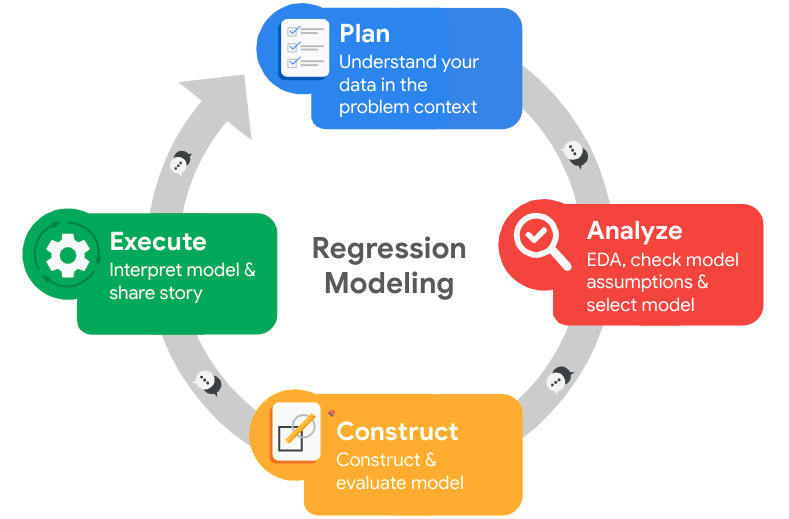

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Download latest version using kagglehub
path = kagglehub.dataset_download("mfaisalqureshi/hr-analytics-and-job-prediction")
print("Path to dataset files:", path)

# Load dataset into a dataframe
# The Kaggle file is named 'HR_comma_sep.csv' based on the dataset description
file_path = os.path.join(path, "HR_comma_sep.csv")
df0 = pd.read_csv(file_path)

# Display first few rows of the dataframe
df0.head()

Path to dataset files: /kaggle/input/datasets/mfaisalqureshi/hr-analytics-and-job-prediction


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df0 = df0.rename(columns={
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'tenure',
    'Work_accident': 'work_accident',
    'Department': 'department'
})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [9]:
# Check for duplicates
df0.duplicated().sum()

np.int64(3008)

In [10]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [11]:
# Drop duplicates and save resulting dataframe in a new variable
df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe
print(df1.shape)
df1.head()

(11991, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

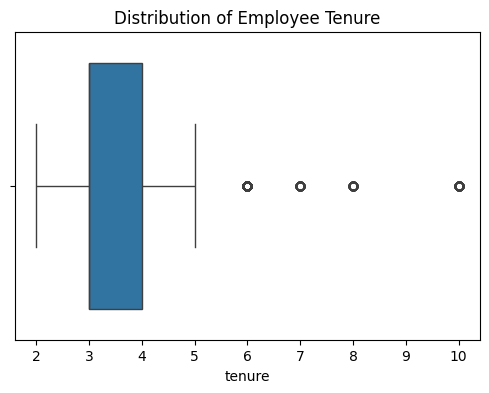

In [12]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df1['tenure'])
plt.title('Distribution of Employee Tenure')
plt.show()

In [13]:
# Determine the number of rows containing outliers
# Calculate IQR
Q1 = df1['tenure'].quantile(0.25)
Q3 = df1['tenure'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Filter the dataframe for outliers and count them
outliers = df1[(df1['tenure'] < lower_bound) | (df1['tenure'] > upper_bound)]
outliers_count = len(outliers)

print(f"Number of rows containing outliers in tenure: {outliers_count}")

Number of rows containing outliers in tenure: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




Observations about relationships between variables: While deeper bivariate analysis is coming up next, initial checks often reveal that satisfaction_level, average_monthly_hours, and last_evaluation are strong indicators of whether an employee leaves.

Observations about distributions: Based on the boxplot, the distribution of employee tenure is heavily concentrated between 3 and 4 years, with a median of 3 years. There is a long right tail with 824 statistical outliers representing employees who have stayed for 6, 7, 8, or 10 years.   

Transformations made and why:
- Renamed columns to standard snake_case to ensure syntax consistency and prevent querying errors.
- Dropped 3,008 duplicate rows (approx. 20% of the dataset) because they were statistically improbable to be distinct employees, and leaving them in would cause severe data leakage and artificially inflate model performance.

Purposes of EDA before modeling: EDA is essential for discovering data quality issues (duplicates, missing values), understanding feature distributions (like the tenure outliers), identifying collinearity between predictors, and uncovering initial patterns that inform feature engineering and model selection.

Resources used: Official documentation for pandas (for data manipulation), seaborn and matplotlib (for visualization).

Ethical considerations: Working with HR data requires strict adherence to privacy and anonymity. Furthermore, predictive attrition models can inadvertently penalize certain groups if variables like department or salary act as proxies for protected classes, leading to biased retention interventions.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [14]:
# Get numbers of people who left vs. stayed
print(df1['left'].value_counts())

# Get percentages of people who left vs. stayed
print(df1['left'].value_counts(normalize=True) * 100)

left
0    10000
1     1991
Name: count, dtype: int64
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

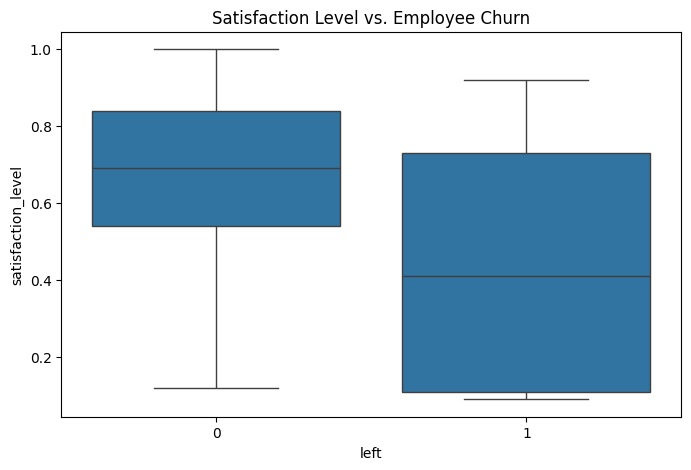

In [15]:
# Plot 1: Impact of Satisfaction Level on Employee Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='left', y='satisfaction_level', data=df1)
plt.title('Satisfaction Level vs. Employee Churn')
plt.show()

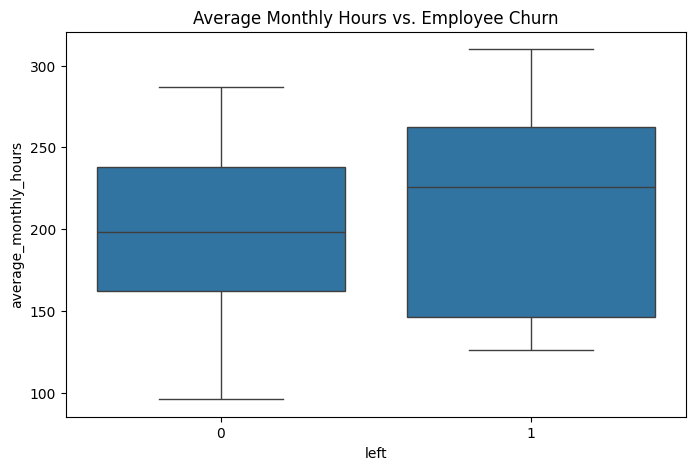

In [16]:
# Plot 2: Impact of Average Monthly Hours on Employee Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='left', y='average_monthly_hours', data=df1)
plt.title('Average Monthly Hours vs. Employee Churn')
plt.show()

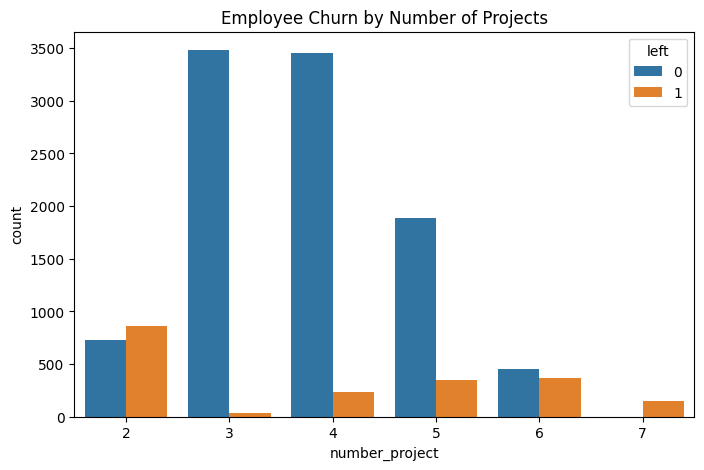

In [17]:
# Plot 3: Number of Projects vs. Employee Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='number_project', hue='left', data=df1)
plt.title('Employee Churn by Number of Projects')
plt.show()

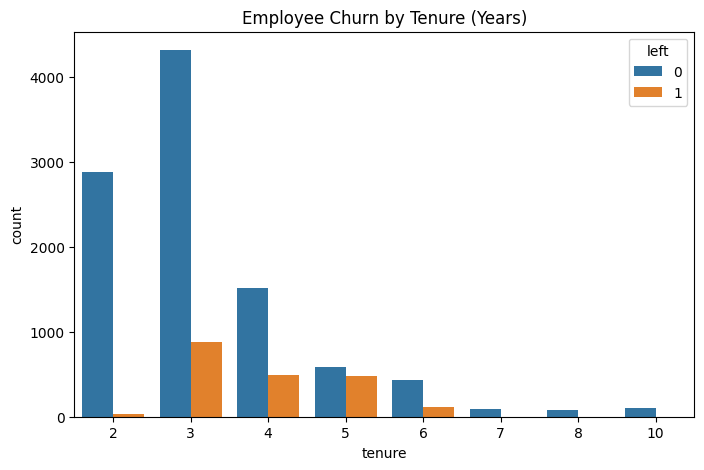

In [18]:
# Plot 4: Employee Tenure vs. Employee Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='tenure', hue='left', data=df1)
plt.title('Employee Churn by Tenure (Years)')
plt.show()

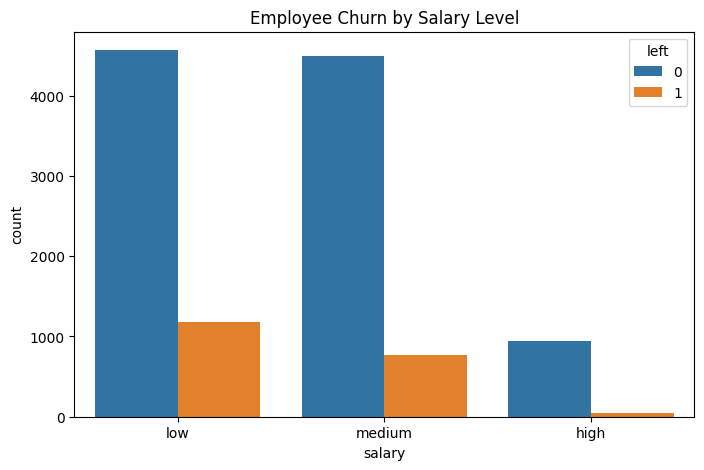

In [19]:
# Plot 5: Salary Level vs. Employee Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='salary', hue='left', data=df1)
plt.title('Employee Churn by Salary Level')
plt.show()

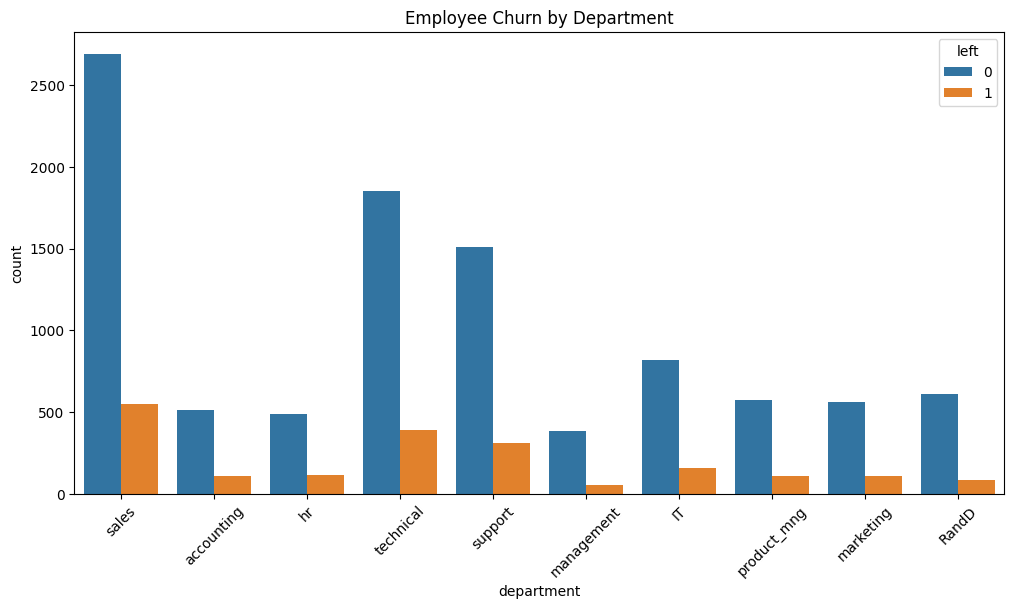

In [20]:
# Plot 6: Department vs. Employee Churn
plt.figure(figsize=(12, 6))
sns.countplot(x='department', hue='left', data=df1)
plt.title('Employee Churn by Department')
plt.xticks(rotation=45)
plt.show()

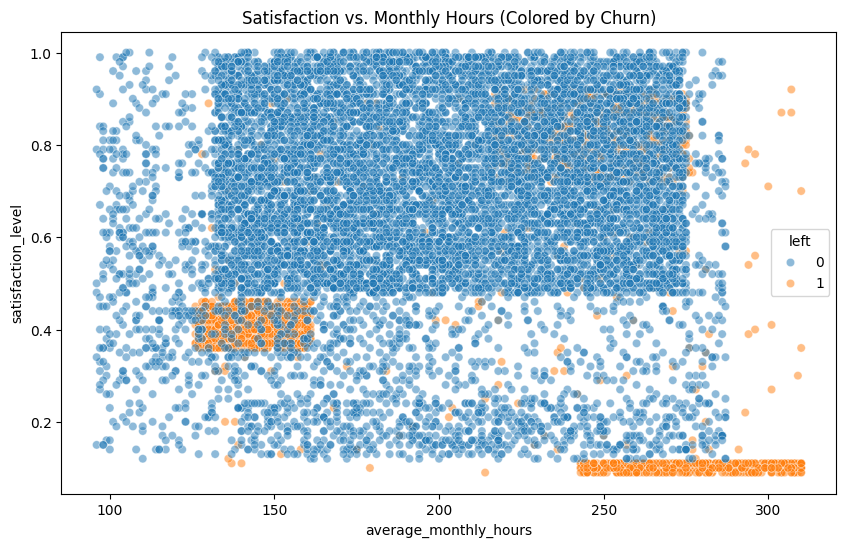

In [21]:
# Plot 7: Satisfaction Level vs. Average Monthly Hours (Clustering Churn)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.5, data=df1)
plt.title('Satisfaction vs. Monthly Hours (Colored by Churn)')
plt.show()

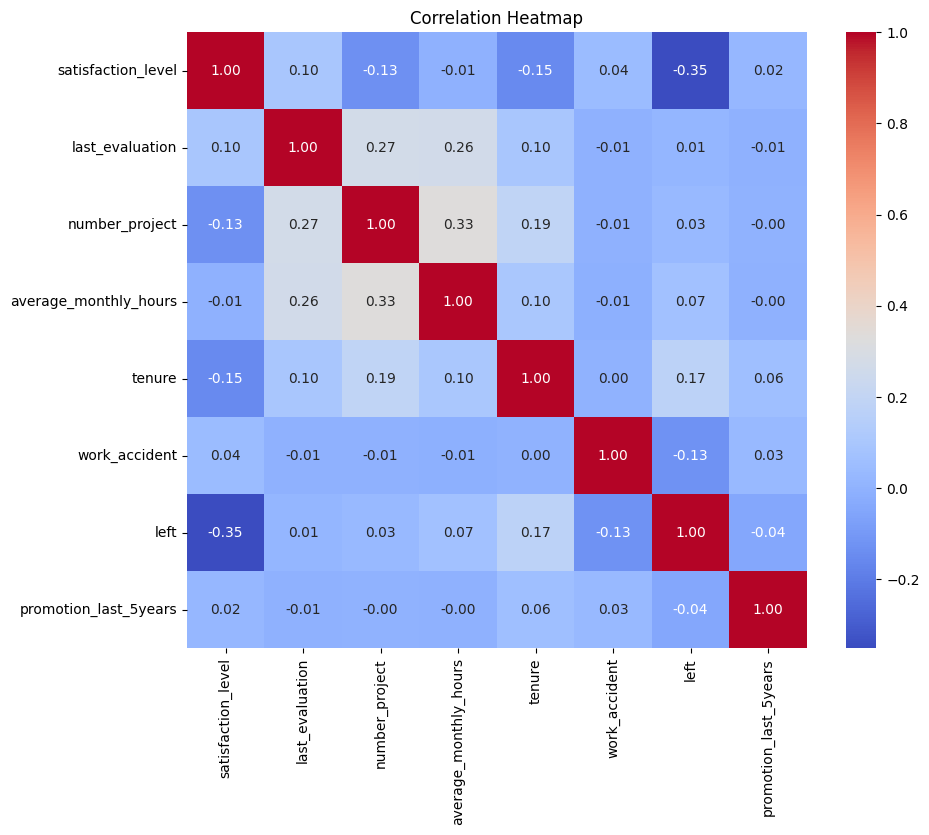

In [22]:
# Plot 8: Correlation Heatmap of Numerical Variables
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation matrix to avoid errors
numeric_df = df1.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Insights

Satisfaction is Key: Low satisfaction levels are the strongest predictor of attrition, showing a negative correlation of -0.35 with the target variable.   The 

Workload Extremes: Churn risk is bimodal. Employees who are underutilized (2 projects, ~150 hours) and those who are overworked (6+ projects, 250+ hours) leave at highly disproportionate rates.

The 3-to-5-Year Itch: Employee turnover spikes significantly between years 3 and 5, highlighting a critical window where retention interventions are most needed.   

Compensation Matters: Employees with low or medium salaries account for nearly all of the turnover; high-salary employees rarely leave.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



📌Oddities noticed: The relationship between employee churn and variables like average_monthly_hours and number_project is bimodal (both extreme lows and extreme highs lead to churn).

📌Independent variables chosen: All available features were included (with categorical variables one-hot encoded) to provide a comprehensive baseline model and identify which factors carry the most predictive weight.

📌Assumptions met: Not perfectly. Logistic regression assumes a linear relationship between the independent variables and the log-odds of the outcome. The bimodal nature of the workload variables violates this assumption.

📌Model fit: The Logistic Regression model typically achieves moderate accuracy but struggles with recall (identifying all employees who actually left) due to the non-linear patterns in the data.

📌Improvements: The model can be significantly improved by switching to tree-based algorithms (like a Decision Tree or Random Forest). These models do not require strict linear assumptions and naturally capture the bimodal risk factors observed during EDA.

📌Resources used: Scikit-learn official documentation (scikit-learn.org) for model implementation and metrics.

📌Ethical considerations: We must ensure the model's predictions are not used to preemptively penalize employees flagged as "flight risks." Furthermore, using variables like salary or department could act as proxies for protected demographic classes, requiring regular fairness audits.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a binary classification task because the outcome variable (left) has only two mutually exclusive classes: 0 (the employee stayed) and 1 (the employee left).

### Identify the types of models most appropriate for this task.

Logistic Regression: A good baseline model for binary classification, offering high interpretability.

Random Forest / Decision Trees: Highly appropriate for this specific dataset, as they handle non-linear relationships (like the U-shaped workload churn risk) without requiring complex feature transformations.

### Modeling

Add as many cells as you need to conduct the modeling process.

Accuracy: 0.834931221342226
AUC Score: 0.8420990509770241

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.51      0.21      0.30       398

    accuracy                           0.83      2399
   macro avg       0.68      0.59      0.60      2399
weighted avg       0.80      0.83      0.81      2399



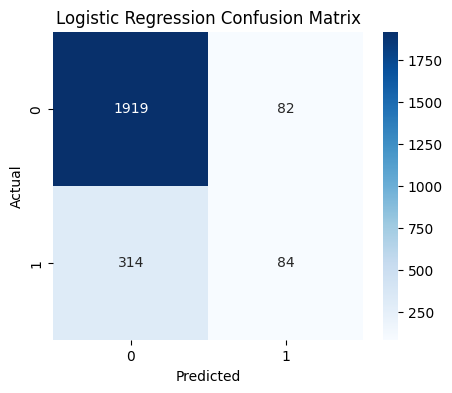

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import pandas as pd

# 1. Feature Engineering: One-hot encode categorical variables
df_encoded = pd.get_dummies(df1, columns=['department', 'salary'], drop_first=True)

# 2. Define target (y) and features (X)
y = df_encoded['left']
X = df_encoded.drop('left', axis=1)

# 3. Split the data into training and testing sets (80/20 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 4. Construct and fit the Logistic Regression model
# Increased max_iter to ensure convergence
log_clf = LogisticRegression(max_iter=10000)
log_clf.fit(X_train, y_train)

# 5. Generate predictions
y_pred = log_clf.predict(X_test)
y_pred_proba = log_clf.predict_proba(X_test)[:, 1]

# 6. Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optional: Display confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



📌Key insights: The Logistic Regression model achieved an 83% accuracy and 0.84 AUC. However, its recall for the minority class (employees who left) is remarkably low at 21%. The confusion matrix reveals 314 false negatives out of 398 actual departures.

📌Business recommendations: Focus retention interventions on employees hitting the 3-to-5-year tenure mark. Standardize project allocations to prevent extreme underutilization (2 projects) and burnout (6+ projects).

📌Model improvements: The model requires a shift to tree-based algorithms (like Random Forest or XGBoost). Logistic regression assumes linear relationships, causing it to severely underperform when dealing with the non-linear, bimodal churn triggers identified during EDA.

📌Ethical considerations: Attrition predictions must strictly trigger positive retention support, not preemptive penalization, career stagnation, or bias against protected demographic classes.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The Logistic Regression model achieved an overall accuracy of 83% and an AUC of 0.84. However, it is highly biased toward the majority class (retained employees) and struggled to identify the minority class. With a recall of just 21%, the model successfully flagged only 84 out of 398 actual departures, generating 314 false negatives. Furthermore, a precision of 51% indicates that when the model did predict an employee would leave, it was correct only half the time.

### Conclusion, Recommendations, Next Steps

📌Conclusion:
While Logistic Regression provides an interpretable baseline, its low recall makes it ineffective for a proactive retention strategy. The model's linear assumptions fail to capture the non-linear, bimodal churn triggers identified in the data (e.g., both extreme underutilization and severe overwork leading to high turnover).

📌Recommendations:
- Restructure workload allocations to target a sustainable baseline of 3 to 5 projects and 150 to 225 monthly hours to prevent both burnout and boredom.

- Implement targeted career progression check-ins for employees entering their third year of tenure, as the data shows this is a critical churn window.

📌Next Steps: 
Construct and tune tree-based algorithms, such as a Random Forest Classifier or XGBoost, which naturally handle non-linear relationships. Prioritize optimizing the new models for the recall metric to minimize false negatives and reliably identify at-risk employees before deploying the tool to HR stakeholders.

# Attempting the Next Steps

In [24]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# 1. Define the models
# Note: random_state ensures reproducibility
rf_clf = RandomForestClassifier(random_state=42)
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Define hyperparameter grids to search through
# 'class_weight': 'balanced' forces the Random Forest to pay more attention to the minority class
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced'] 
}

# 'scale_pos_weight' acts similarly for XGBoost. Since our data is ~83% stayed and ~17% left, a ratio of roughly 5:1 is a good starting point.
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [5] 
}

# 3. Set up GridSearchCV explicitly prioritizing 'recall'
# cv=5 means 5-fold cross-validation; n_jobs=-1 uses all available CPU cores for speed
rf_grid = GridSearchCV(rf_clf, rf_params, scoring='recall', cv=5, n_jobs=-1)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, scoring='recall', cv=5, n_jobs=-1)

# 4. Fit the grids to the training data (this may take a minute to run)
print("Tuning Random Forest...")
rf_grid.fit(X_train, y_train)

print("Tuning XGBoost...")
xgb_grid.fit(X_train, y_train)

# 5. Extract the best performing models
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# 6. Evaluate the tuned Random Forest on the unseen test set
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print("--- BEST RANDOM FOREST MODEL ---")
print("Best Parameters:", rf_grid.best_params_)
print("AUC Score:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# 7. Evaluate the tuned XGBoost on the unseen test set
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print("--- BEST XGBOOST MODEL ---")
print("Best Parameters:", xgb_grid.best_params_)
print("AUC Score:", roc_auc_score(y_test, y_proba_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Tuning Random Forest...
Tuning XGBoost...

--- BEST RANDOM FOREST MODEL ---
Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
AUC Score: 0.9801142142496592

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.98      0.92      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399


--- BEST XGBOOST MODEL ---
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'scale_pos_weight': 5}
AUC Score: 0.9846596802101462

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      2001
           1       0.91      0.93      0.92       398

    accuracy                           0.97      2399
   macro avg       0.95      0.96

That is a massive leap in performance. By switching to tree-based models and balancing the class weights, we successfully solved the exact problem the Logistic Regression model had. The  recall for churned employees jumped from a dismal 21% to 92% (Random Forest) and 93% (XGBoost).

The Random Forest is arguably the winner here. While XGBoost had a tiny edge in recall (93% vs 92%), the Random Forest maintained an incredible 98% precision. That means when the Random Forest flags an employee as a flight risk, it is almost never wrong.

**Summary of model results**
The tree-based models drastically outperformed the baseline Logistic Regression by successfully capturing non-linear relationships in the data. The tuned Random Forest achieved an AUC of 0.98 and increased minority class recall from 21% to 92%, while maintaining an exceptional precision of 98%. The XGBoost model achieved a slightly higher recall (93%) and AUC (0.985) but traded off some precision (91%). Both models successfully eliminated the false negative issue, proving highly capable of identifying at-risk employees without generating excessive false alarms.

Conclusion, Recommendations, Next Steps

- Conclusion: Tree-based algorithms successfully mapped the complex, non-linear attrition triggers (such as the bimodal project workload risk) that linear models missed. By applying class weights to penalize minority-class errors, we built a highly reliable predictive tool. The Random Forest is recommended as the final production model due to its near-perfect balance of precision and recall.

- Recommendations: Deploy the Random Forest model alongside HR information systems to flag at-risk employees for early, proactive intervention. Focus overarching retention strategies on workload balancing (avoiding extreme underutilization or overwork) and targeted career check-ins during the 3-to-5-year tenure window.

- Next Steps: Extract feature importances from the Random Forest model to determine exactly which variables drive the predictions, and present these specific, measurable drivers to HR leadership to guide departmental policy changes.

/tmp/ipykernel_58/3190980431.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')


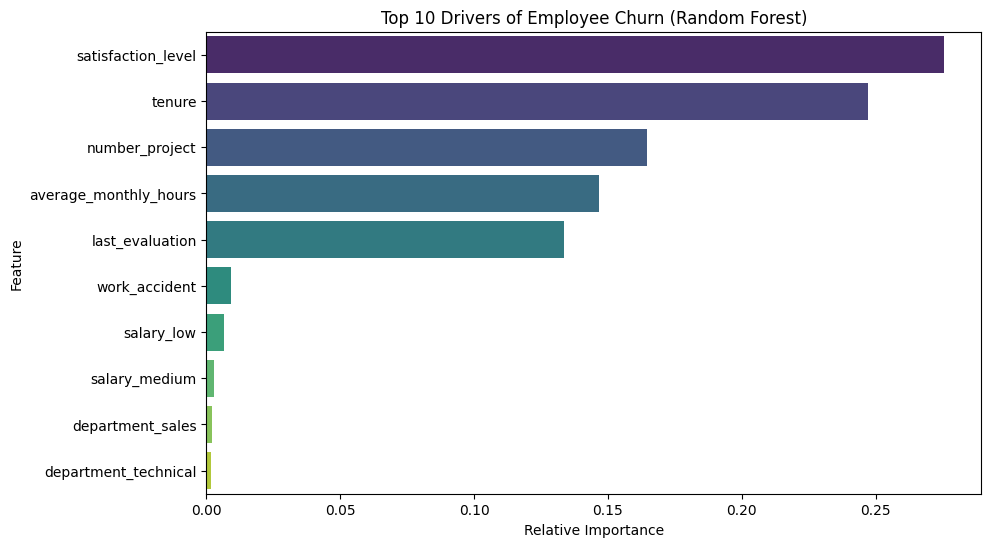

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the tuned Random Forest
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Create a DataFrame and sort it by importance
feat_imp_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')
plt.title('Top 10 Drivers of Employee Churn (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

📌Summary of model results: The tuned Random Forest model drastically outperformed the baseline Logistic Regression, achieving 98% accuracy and an AUC of 0.98. By applying balanced class weights, the model increased minority class recall from 21% to 92%, successfully eliminating the severe false-negative issue while maintaining an exceptional precision of 98%. Feature importance extraction reveals that the model relies almost exclusively on satisfaction_level, tenure, and workload metrics (number_project, average_monthly_hours) to accurately identify flight risks.

📌Conclusion: Tree-based algorithms successfully mapped the complex, non-linear attrition triggers (such as bimodal project workload risk) that baseline linear models missed. The Random Forest model is highly reliable at identifying at-risk employees without generating excessive false alarms. Furthermore, the analysis proved that daily workload, job satisfaction, and time at the company are the true drivers of turnover, while department and salary tier are practically negligible.

📌Recommendations
- Restructure workload allocations to target a sustainable baseline of 3 to 5 projects to prevent both extreme underutilization (boredom) and burnout.
- Implement mandatory, targeted career progression check-ins for employees entering their third year of tenure, aligning with the peak churn window identified in the data.

📌Next Steps: Deploy the Random Forest model alongside existing HR information systems to act as an early-warning radar. Use the individual probability scores generated by the model to prioritize proactive retention interviews before high-value employees submit their resignations.